IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

LOAD DATASET

In [2]:
data_path = "/content/drive/MyDrive/Colab Notebooks/breast-cancer-wisconsin.data.csv"
df = pd.read_csv(data_path)

DATA CLEANING

In [12]:
df = df.replace("?", np.nan)

Convert numeric columns safely

In [13]:
for col in df.columns[1:]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

Fill missing values ONLY for numeric columns

In [14]:
df.iloc[:, 1:] = df.iloc[:, 1:].fillna(df.iloc[:, 1:].mean())

 TARGET COLUMN DETECTION

In [15]:
y = df.iloc[:, 0]          # FIRST column = target
X = df.iloc[:, 1:]

In [16]:
if y.dtype == "object":
    y = LabelEncoder().fit_transform(y)

TRAIN–TEST SPLIT

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

FEATURE SCALING

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

MODEL WITH ALL FEATURES

In [22]:
lr_all = LogisticRegression(max_iter=1000, solver="liblinear")
lr_all.fit(X_train_scaled, y_train)

y_pred_all = lr_all.predict(X_test_scaled)
y_prob_all = lr_all.predict_proba(X_test_scaled)[:, 1]
print("MODEL USING ALL FEATURES")
print("Accuracy:", accuracy_score(y_test, y_pred_all))
print("Precision:", precision_score(y_test, y_pred_all, average='macro'))
print("Recall:", recall_score(y_test, y_pred_all, average='macro'))
print("F1-score:", f1_score(y_test, y_pred_all, average='macro'))


MODEL USING ALL FEATURES
Accuracy: 0.0
Precision: 0.0
Recall: 0.0
F1-score: 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


ROC CURVE

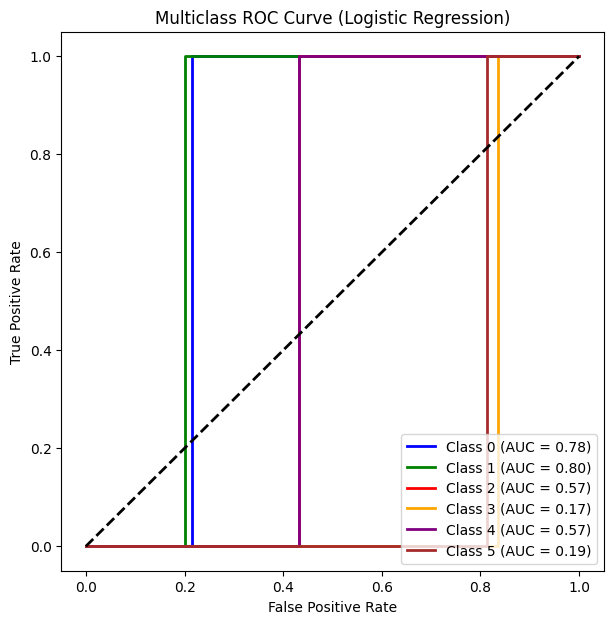

In [26]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_bin.shape[1]
y_prob_all = lr_all.predict_proba(X_test_scaled)
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob_all[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(7,7))
colors = ['blue', 'green', 'red', 'orange', 'purple', 'brown']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve (Logistic Regression)")
plt.legend(loc="lower right")
plt.show()



TOP 3 & TOP 7 FEATURES


Performance with Top 3 Features:
Accuracy: 0.0
Precision (macro): 0.0
Recall (macro): 0.0
F1-score (macro): 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


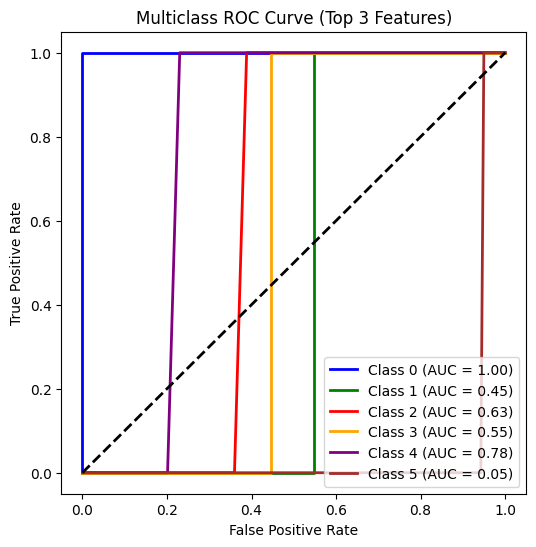

----------------------------------------
Performance with Top 7 Features:
Accuracy: 0.0
Precision (macro): 0.0
Recall (macro): 0.0
F1-score (macro): 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


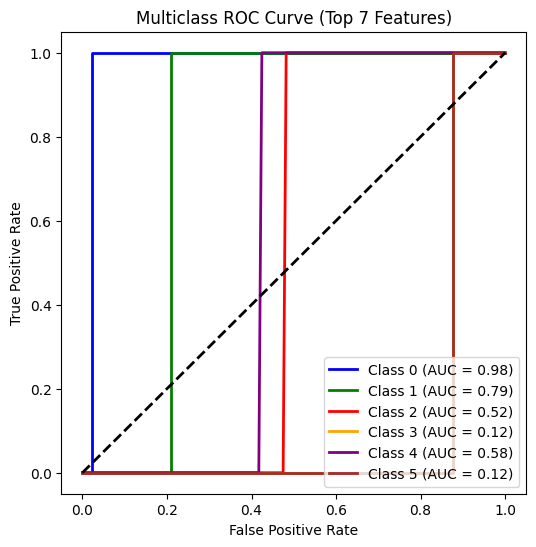

----------------------------------------


In [29]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

for n in [3, 7]:
    rfe_exp = RFE(estimator=LogisticRegression(max_iter=1000, solver="liblinear"), n_features_to_select=n)
    rfe_exp.fit(X_train_scaled, y_train)

    X_train_exp = rfe_exp.transform(X_train_scaled)
    X_test_exp = rfe_exp.transform(X_test_scaled)

    lr_exp = LogisticRegression(max_iter=1000, solver="liblinear")
    lr_exp.fit(X_train_exp, y_train)

    y_pred_exp = lr_exp.predict(X_test_exp)
    y_prob_exp = lr_exp.predict_proba(X_test_exp)  # Probabilities for ROC

    # Metrics
    print(f"Performance with Top {n} Features:")
    print("Accuracy:", accuracy_score(y_test, y_pred_exp))
    print("Precision (macro):", precision_score(y_test, y_pred_exp, average='macro'))
    print("Recall (macro):", recall_score(y_test, y_pred_exp, average='macro'))
    print("F1-score (macro):", f1_score(y_test, y_pred_exp, average='macro'))

    # Multiclass ROC
    y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
    n_classes = y_test_bin.shape[1]

    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob_exp[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(6,6))
    colors = ['blue', 'green', 'red', 'orange', 'purple', 'brown']
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'Class {i} (AUC = {roc_auc[i]:.2f})')
    plt.plot([0,1],[0,1],'k--', lw=2)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Multiclass ROC Curve (Top {n} Features)")
    plt.legend(loc="lower right")
    plt.show()
    print("-"*40)


